Max values for each metric:
  accuracy  max = 0.8303 at threshold = 0.470
  precision max = 1.0000 at threshold = 0.980
  recall    max = 1.0000 at threshold = 0.000
  f1        max = 0.8150 at threshold = 0.440

Crossing (closest) thresholds between metric pairs:
  accuracy  and precision closest at threshold ≈ 0.630 (0.8166 vs 0.8133)
  accuracy  and recall    closest at threshold ≈ 0.510 (0.8279 vs 0.8357)
  accuracy  and f1        closest at threshold ≈ 0.300 (0.8097 vs 0.8097)
  precision and recall    closest at threshold ≈ 0.570 (0.7918 vs 0.7974)
  precision and f1        closest at threshold ≈ 0.570 (0.7918 vs 0.7946)
  recall    and f1        closest at threshold ≈ 0.570 (0.7974 vs 0.7946)


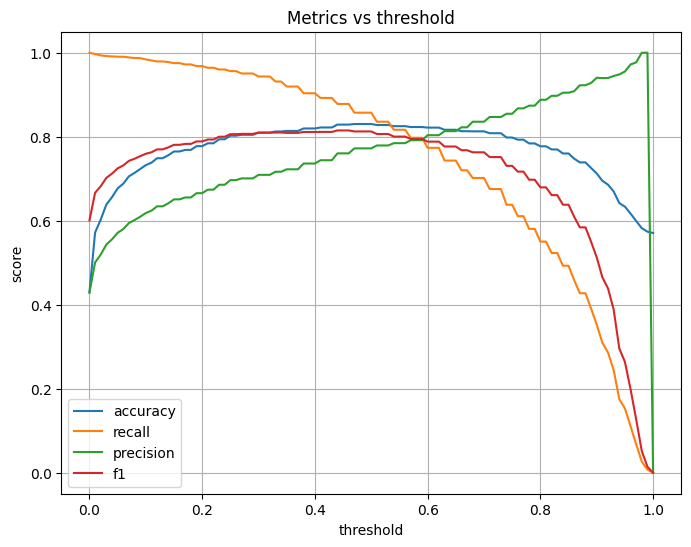

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv('out/mof_cls_holdout_eval.csv')
y_true = (df['gold_label'] == 'P').astype(int)
prob = df['prob_P']

thresholds = np.linspace(0, 1, 101)
acc, prec, rec, f1 = [], [], [], []

for t in thresholds:
    y_pred = (prob >= t).astype(int)
    acc.append(accuracy_score(y_true, y_pred))
    prec.append(precision_score(y_true, y_pred, zero_division=0))
    rec.append(recall_score(y_true, y_pred, zero_division=0))
    f1.append(f1_score(y_true, y_pred, zero_division=0))

acc = np.array(acc)
prec = np.array(prec)
rec = np.array(rec)
f1 = np.array(f1)

metrics = {
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1": f1,
}

# 1) Maxima for each metric
print("Max values for each metric:")
for name, values in metrics.items():
    i = np.argmax(values)
    print(f"  {name:9s} max = {values[i]:.4f} at threshold = {thresholds[i]:.3f}")

# 2) One "best" crossing per pair, ignoring 0 and 1 if we can
print("\nCrossing (closest) thresholds between metric pairs:")
metric_names = list(metrics.keys())

for i in range(len(metric_names)):
    for j in range(i + 1, len(metric_names)):
        m1, m2 = metric_names[i], metric_names[j]
        v1, v2 = metrics[m1], metrics[m2]

        diff = v1 - v2

        # prefer interior thresholds (0,1 excluded) if available
        interior_mask = (thresholds > 0) & (thresholds < 1)
        if interior_mask.any():
            th = thresholds[interior_mask]
            d  = diff[interior_mask]
            v1m = v1[interior_mask]
            v2m = v2[interior_mask]
        else:
            th = thresholds
            d  = diff
            v1m = v1
            v2m = v2

        # index where |difference| is smallest
        k = np.argmin(np.abs(d))
        t_cross = th[k]

        # metric values there
        v1_cross = v1m[k]
        v2_cross = v2m[k]

        print(
            f"  {m1:9s} and {m2:9s} closest at threshold ≈ {t_cross:.3f} "
            f"({v1_cross:.4f} vs {v2_cross:.4f})"
        )

# Plot
plt.figure(figsize=(8, 6))
plt.plot(thresholds, acc, label='accuracy')
plt.plot(thresholds, rec, label='recall')
plt.plot(thresholds, prec, label='precision')
plt.plot(thresholds, f1, label='f1')
plt.xlabel('threshold')
plt.ylabel('score')
plt.title('Metrics vs threshold')
plt.legend()
plt.grid(True)
plt.show()


Loaded files: ['out\\mof_cls_holdout_eval_1.csv', 'out\\mof_cls_holdout_eval_2.csv', 'out\\mof_cls_holdout_eval_3.csv', 'out\\mof_cls_holdout_eval_4.csv', 'out\\mof_cls_holdout_eval_5.csv']


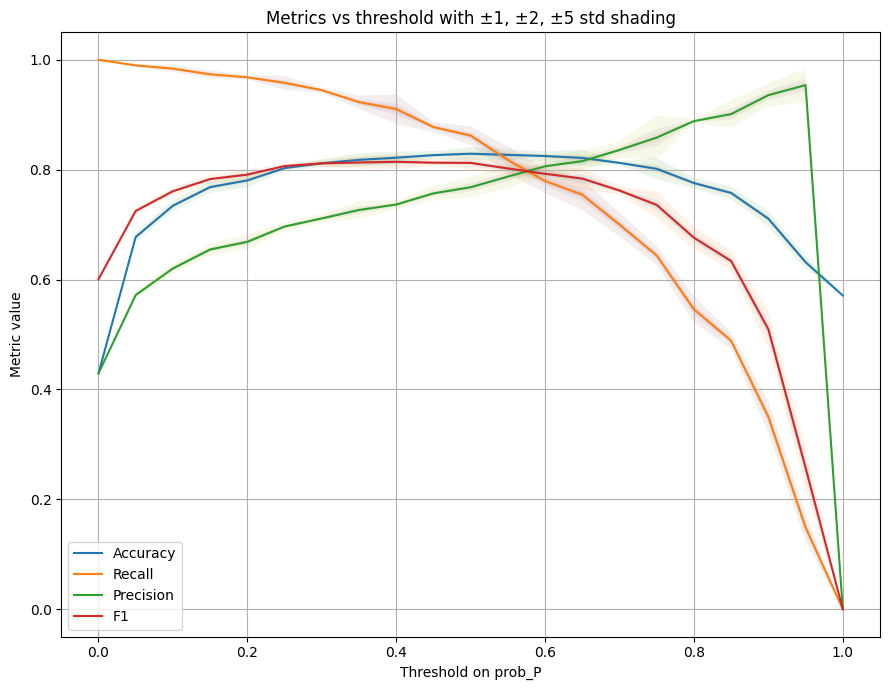

      model       acc       pre       rec        f1
0     run_1  0.826831  0.764498  0.862041  0.810345
1     run_2  0.826146  0.763047  0.862839  0.809880
2     run_3  0.829227  0.769066  0.860447  0.812194
3     run_4  0.832649  0.771084  0.867624  0.816510
4     run_5  0.830253  0.772270  0.857257  0.812547
5  avg_prob  0.831280  0.773938  0.857257  0.813470
6  majority  0.830595  0.768577  0.866029  0.814398


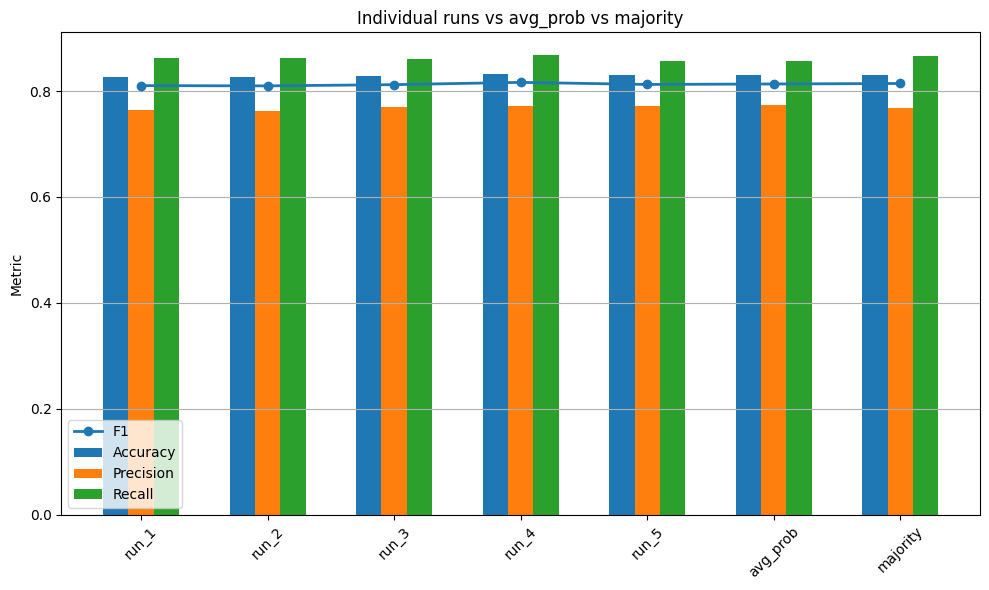

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob

# -------------------------------------------------------------------
# Load data
# -------------------------------------------------------------------
paths = sorted(glob("out\mof_cls_holdout_eval_*.csv"))
dfs = [pd.read_csv(p) for p in paths]
print("Loaded files:", paths)

# -------------------------------------------------------------------
# Helper to compute metrics vs threshold for one run
# -------------------------------------------------------------------
def metrics_vs_threshold(df, thresholds):
    y = (df["gold_label"] == "P").astype(int).values
    p = df["prob_P"].values

    acc, rec, pre, f1 = [], [], [], []
    n = len(y)

    for t in thresholds:
        yp = (p >= t).astype(int)
        tp = ((yp == 1) & (y == 1)).sum()
        tn = ((yp == 0) & (y == 0)).sum()
        fp = ((yp == 1) & (y == 0)).sum()
        fn = ((yp == 0) & (y == 1)).sum()

        acc_t = (tp + tn) / n
        pre_t = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec_t = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1_t = 2 * pre_t * rec_t / (pre_t + rec_t) if (pre_t + rec_t) > 0 else 0.0

        acc.append(acc_t)
        pre.append(pre_t)
        rec.append(rec_t)
        f1.append(f1_t)

    return np.array(acc), np.array(rec), np.array(pre), np.array(f1)

# -------------------------------------------------------------------
# 1) SHADED PLOT: mean metrics vs threshold with ±1, ±2, ±5 std bands
# -------------------------------------------------------------------
thresholds = np.arange(0.0, 1.001, 0.05)

all_acc, all_rec, all_pre, all_f1 = [], [], [], []
for df in dfs:
    a, r, p, f = metrics_vs_threshold(df, thresholds)
    all_acc.append(a)
    all_rec.append(r)
    all_pre.append(p)
    all_f1.append(f)

all_acc = np.vstack(all_acc)
all_rec = np.vstack(all_rec)
all_pre = np.vstack(all_pre)
all_f1 = np.vstack(all_f1)

mean_acc, std_acc = all_acc.mean(0), all_acc.std(0)
mean_rec, std_rec = all_rec.mean(0), all_rec.std(0)
mean_pre, std_pre = all_pre.mean(0), all_pre.std(0)
mean_f1,  std_f1  = all_f1.mean(0),  all_f1.std(0)

def plot_with_bands(thresholds, mean, std, label):
    plt.plot(thresholds, mean, label=label)
    for k in [1, 2, 5]:
        plt.fill_between(
            thresholds,
            mean - k * std,
            mean + k * std,
            alpha=0.1
        )

plt.figure(figsize=(9, 7))
plot_with_bands(thresholds, mean_acc, std_acc, "Accuracy")
plot_with_bands(thresholds, mean_rec, std_rec, "Recall")
plot_with_bands(thresholds, mean_pre, std_pre, "Precision")
plot_with_bands(thresholds, mean_f1,  std_f1,  "F1")

plt.xlabel("Threshold on prob_P")
plt.ylabel("Metric value")
plt.title("Metrics vs threshold with ±1, ±2, ±5 std shading")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 2) TABLE AND PLOT: individual runs vs avg_prob vs majority vote
#    (all at fixed threshold 0.5)
# -------------------------------------------------------------------
# Merge the 5 runs on example_index to create ensembles
merged = dfs[0][["example_index", "gold_label", "prob_P"]].rename(
    columns={"prob_P": "prob_P_1"}
)
for i, df in enumerate(dfs[1:], start=2):
    merged = merged.merge(
        df[["example_index", "prob_P"]],
        on="example_index",
        suffixes=("", f"_{i}")
    )
    merged = merged.rename(columns={"prob_P": f"prob_P_{i}"})

prob_cols = [c for c in merged.columns if c.startswith("prob_P_")]

# Binary predictions from each run at threshold 0.5
for c in prob_cols:
    merged[c.replace("prob_P", "pred")] = (merged[c] >= 0.5).astype(int)
pred_cols = [c for c in merged.columns if c.startswith("pred_")]

# Majority vote over 5 runs
merged["maj_pred"] = (merged[pred_cols].sum(axis=1) >= 3).astype(int)

# Average probability ensemble
merged["avg_prob"] = merged[prob_cols].mean(axis=1)
merged["avg_pred"] = (merged["avg_prob"] >= 0.5).astype(int)

# Metrics helper for a single prediction vector
def get_metrics(y_true, y_pred):
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    acc = (tp + tn) / len(y_true)
    pre = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * pre * rec / (pre + rec) if (pre + rec) > 0 else 0.0
    return acc, pre, rec, f1

y_true_all = (merged["gold_label"] == "P").astype(int).values

# Individual runs
rows = []
for i, df in enumerate(dfs, start=1):
    y_true = (df["gold_label"] == "P").astype(int).values
    y_pred = (df["prob_P"] >= 0.5).astype(int).values
    acc, pre, rec, f1 = get_metrics(y_true, y_pred)
    rows.append([f"run_{i}", acc, pre, rec, f1])

# Ensembles
avg_acc, avg_pre, avg_rec, avg_f1 = get_metrics(
    y_true_all, merged["avg_pred"].values
)
maj_acc, maj_pre, maj_rec, maj_f1 = get_metrics(
    y_true_all, merged["maj_pred"].values
)

rows.append(["avg_prob", avg_acc, avg_pre, avg_rec, avg_f1])
rows.append(["majority", maj_acc, maj_pre, maj_rec, maj_f1])

table = pd.DataFrame(rows, columns=["model", "acc", "pre", "rec", "f1"])
print(table)

# Bar plot of these metrics
labels = table["model"].values
accs   = table["acc"].values
pres   = table["pre"].values
recs   = table["rec"].values
f1s    = table["f1"].values

x = np.arange(len(labels))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - width, accs, width, label="Accuracy")
plt.bar(x,         pres, width, label="Precision")
plt.bar(x + width, recs, width, label="Recall")
plt.plot(x, f1s, marker="o", linewidth=2, label="F1")

plt.xticks(x, labels, rotation=45)
plt.ylabel("Metric")
plt.title("Individual runs vs avg_prob vs majority")
plt.grid(True, axis="y")
plt.legend()
plt.tight_layout()
plt.show()


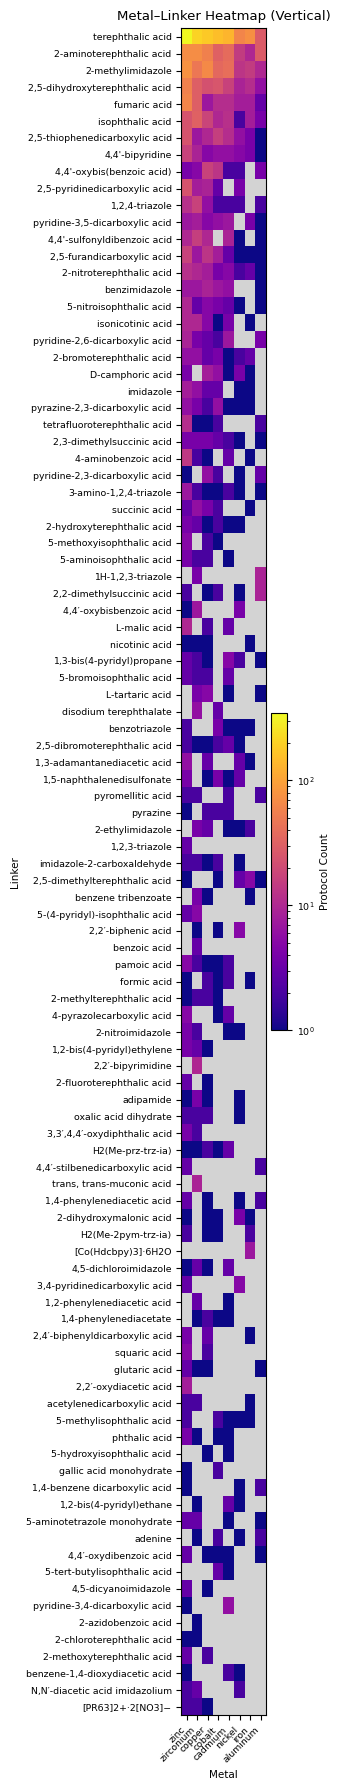

Saved vertical heat map: vertical_heatmap.svg


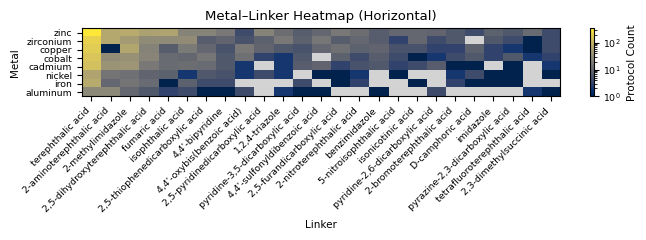

Saved horizontal heat map: horizontal_heatmap.svg


In [76]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, PowerNorm

# =============================================================
# 1. Load Data
# =============================================================
path = "mof_extraction_1_2_3_4_5_6.csv"
df = pd.read_csv(path)

# =============================================================
# 2. General Utilities
# =============================================================
def extract_metal_from_desc(desc: str):
    if not isinstance(desc, str):
        return None
    m = re.search(r"\b(?:a|an)\s+([a-z]+)\s+metal-organic framework", desc, flags=re.IGNORECASE)
    return m.group(1).lower().strip() if m else None

df["metal_from_desc"] = df["mof_description"].apply(extract_metal_from_desc)

# =============================================================
# 3. BASE FUNCTION used by both vertical & horizontal
# =============================================================
def prepare_heat_data(
    df,
    linker_col="linker_1",
    desc_col="mof_description",
    top_n_linkers=20,
    top_n_metals=8,
    linker_max_len=35,
    drop_linkers=None
):
    df = df.copy()

    if drop_linkers:
        df = df[~df[linker_col].isin(drop_linkers)]

    sub = df.dropna(subset=[linker_col, "metal_from_desc"]).copy()
    sub[linker_col] = sub[linker_col].astype(str).str.strip()
    sub["metal_from_desc"] = sub["metal_from_desc"].astype(str).str.strip()

    sub = sub[sub[linker_col].str.len() <= linker_max_len]

    top_linkers = sub[linker_col].value_counts().head(top_n_linkers).index.tolist()
    top_metals = sub["metal_from_desc"].value_counts().head(top_n_metals).index.tolist()

    sub = sub[sub[linker_col].isin(top_linkers) & sub["metal_from_desc"].isin(top_metals)]

    heat_data = (
        sub.groupby([linker_col, "metal_from_desc"])
           .size()
           .unstack(fill_value=0)
           .reindex(index=top_linkers, columns=top_metals, fill_value=0)
    )

    return heat_data, top_linkers, top_metals

# =============================================================
# 4. Vertical Plot Function
# =============================================================
def plot_vertical_heatmap(
    df,
    top_n_linkers=20,
    top_n_metals=8,
    height=7,
    width=6,
    color_map="plasma",
    norm_scale="log",
    bad_cells=None,
    bad_value_for_color=1.0,
    linker_max_len=35,
    drop_linkers=None,
    save_path="vertical_heatmap.svg",
    font_size=10,     # new parameter
):
    heat_data, top_linkers, top_metals = prepare_heat_data(
        df,
        top_n_linkers=top_n_linkers,
        top_n_metals=top_n_metals,
        linker_max_len=linker_max_len,
        drop_linkers=drop_linkers
    )

    data = heat_data.to_numpy().astype(float)

    if bad_cells:
        for r, c in bad_cells:
            r0 = r - 1
            c0 = c - 1
            if 0 <= r0 < data.shape[0] and 0 <= c0 < data.shape[1]:
                data[r0, c0] = bad_value_for_color

    masked = np.ma.masked_where(data == 0, data)

    if norm_scale == "log":
        vmin = max(masked.min(), 1)
        norm = LogNorm(vmin=vmin, vmax=masked.max())
    elif norm_scale == "sqrt":
        norm = PowerNorm(gamma=0.5, vmin=masked.min(), vmax=masked.max())
    else:
        norm = Normalize(vmin=masked.min(), vmax=masked.max())

    cmap = plt.get_cmap(color_map).copy()
    cmap.set_bad(color="lightgray")

    fig, ax = plt.subplots(figsize=(width, height))
    im = ax.imshow(masked, cmap=cmap, norm=norm, aspect="auto")

    ax.set_xticks(np.arange(len(top_metals)))
    ax.set_yticks(np.arange(len(top_linkers)))
    ax.set_xticklabels(top_metals, rotation=45, ha="right", fontsize=font_size*0.9)
    ax.set_yticklabels(top_linkers, fontsize=font_size*0.9)

    ax.set_xlabel("Metal", fontsize=font_size)
    ax.set_ylabel("Linker", fontsize=font_size)
    ax.set_title("Metal–Linker Heatmap (Vertical)", fontsize=font_size+2)

    ax.tick_params(axis="both", which="both", labelsize=font_size*0.9)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Protocol Count", fontsize=font_size)
    cbar.ax.tick_params(labelsize=font_size*0.9)

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    print(f"Saved vertical heat map: {save_path}")


def plot_horizontal_heatmap(
    df,
    top_n_linkers=20,
    top_n_metals=8,
    height=7,
    width=10,
    color_map="viridis",
    norm_scale="linear",
    bad_cells=None,
    bad_value_for_color=1.0,
    linker_max_len=35,
    drop_linkers=None,
    save_path="horizontal_heatmap.svg",
    font_size=10,     # new parameter
):
    heat_data, top_linkers, top_metals = prepare_heat_data(
        df,
        top_n_linkers=top_n_linkers,
        top_n_metals=top_n_metals,
        linker_max_len=linker_max_len,
        drop_linkers=drop_linkers
    )

    data = heat_data.to_numpy().astype(float)

    if bad_cells:
        for r, c in bad_cells:
            r0 = r - 1
            c0 = c - 1
            if 0 <= r0 < data.shape[0] and 0 <= c0 < data.shape[1]:
                data[r0, c0] = bad_value_for_color

    masked = np.ma.masked_where(data == 0, data)
    masked = masked.T

    if norm_scale == "log":
        vmin = max(masked.min(), 1)
        norm = LogNorm(vmin=vmin, vmax=masked.max())
    elif norm_scale == "sqrt":
        norm = PowerNorm(gamma=0.5, vmin=masked.min(), vmax=masked.max())
    else:
        norm = Normalize(vmin=masked.min(), vmax=masked.max())

    cmap = plt.get_cmap(color_map).copy()
    cmap.set_bad(color="lightgray")

    fig, ax = plt.subplots(figsize=(width, height))
    im = ax.imshow(masked, cmap=cmap, norm=norm, aspect="auto")

    ax.set_xticks(np.arange(len(top_linkers)))
    ax.set_yticks(np.arange(len(top_metals)))
    ax.set_xticklabels(top_linkers, rotation=45, ha="right", fontsize=font_size*0.9)
    ax.set_yticklabels(top_metals, fontsize=font_size*0.9)

    ax.set_xlabel("Linker", fontsize=font_size)
    ax.set_ylabel("Metal", fontsize=font_size)
    ax.set_title("Metal–Linker Heatmap (Horizontal)", fontsize=font_size+2)

    ax.tick_params(axis="both", which="both", labelsize=font_size*0.9)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Protocol Count", fontsize=font_size)
    cbar.ax.tick_params(labelsize=font_size*0.9)

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    print(f"Saved horizontal heat map: {save_path}")


# =============================================================
# Example User Runs
# =============================================================

# Vertical settings independent
plot_vertical_heatmap(
    df,
    top_n_linkers=100,
    top_n_metals=8,
    height=18,
    width=3.5,
    color_map="plasma",
    norm_scale="log",
    bad_cells=[(17, 8), (15, 8), (14, 8)],
    linker_max_len=30,
    drop_linkers=["HOOCC6H4CH2PO(OH)(OC2H5)", "disodium isophthalate", "D-(+)-camphoric acid"],
    save_path="vertical_heatmap.svg",
    font_size=7.5,
)



# Horizontal settings independent
plot_horizontal_heatmap(
    df,
    top_n_linkers=25,
    top_n_metals=8,
    height=2.5,
    width=7,
    color_map="cividis",
    norm_scale="log",
    bad_cells=[(2, 3), (5, 7)],
    linker_max_len=30,
    drop_linkers=["HOOCC6H4CH2PO(OH)(OC2H5)", "disodium isophthalate", "D-(+)-camphoric acid"],
    save_path="horizontal_heatmap.svg",
    font_size=7.5,
    
)


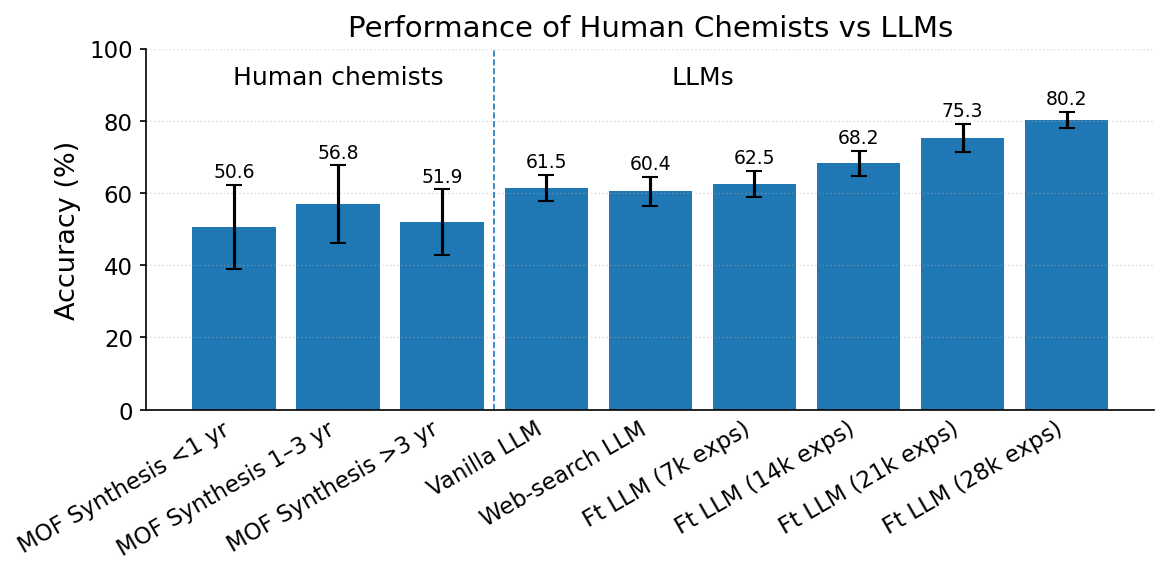

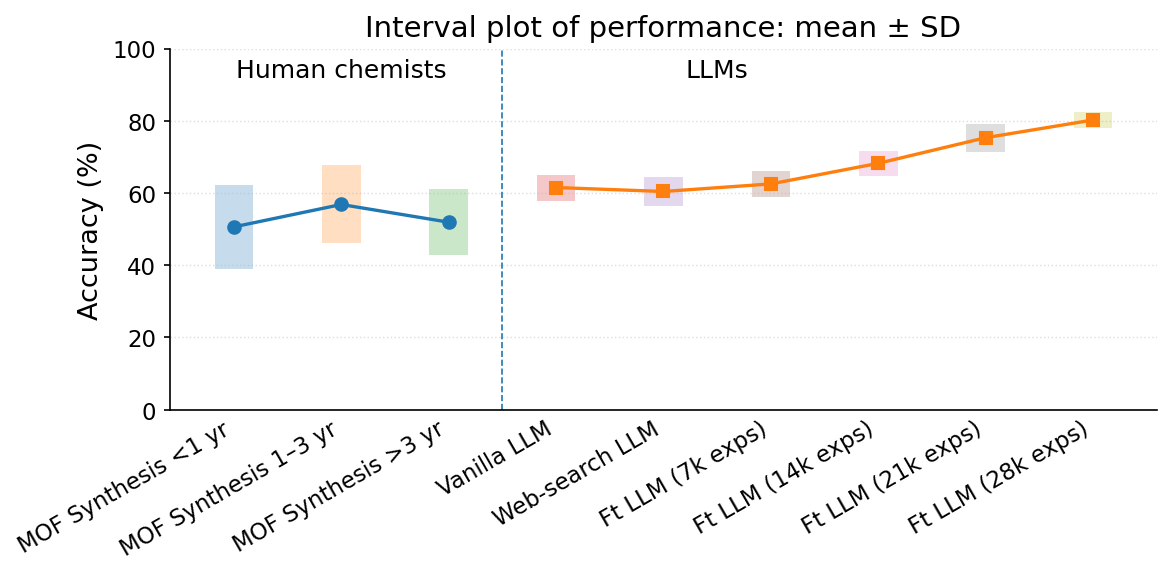

In [89]:
import numpy as np
import matplotlib.pyplot as plt

# Data
labels = [
    "MOF Synthesis <1 yr",
    "MOF Synthesis 1–3 yr",
    "MOF Synthesis >3 yr",
    "Vanilla LLM",
    "Web-search LLM",
    "Ft LLM (7k exps)",
    "Ft LLM (14k exps)",
    "Ft LLM (21k exps)",
    "Ft LLM (28k exps)",
]
acc = np.array([50.6, 56.8, 51.9, 61.5, 60.4, 62.5,68.2,75.3, 80.2])
std = np.array([11.6, 10.8, 9.1, 3.6, 4.1, 3.7,3.5, 3.9, 2.2])
idx = np.arange(len(labels))

# Global style tweaks
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle=":", linewidth=0.7, alpha=0.4)
    ax.tick_params(axis="x", length=0)
    ax.tick_params(axis="y", length=3)


# -------------------------------------------------------------------------
# 1. Sectioned bar plot with error bars, labels, Humans vs LLMs split
# -------------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(8, 4))

ax1.bar(idx, acc, yerr=std, capsize=4)
ax1.set_ylabel("Accuracy (%)")
ax1.set_xticks(idx)
ax1.set_xticklabels(labels, rotation=30, ha="right")
ax1.set_ylim(0, 100)
ax1.set_title("Performance of Human Chemists vs LLMs")

# Vertical separator between human chemists (0 1 2) and LLMs (3 4 5)
ax1.axvline(2.5, linestyle="--", linewidth=0.8)

# Section labels
ax1.text(1.0, 92, "Human chemists", ha="center", va="center")
ax1.text(4.5, 92, "LLMs", ha="center", va="center")

# Numeric labels above bars
for i, (m, s) in enumerate(zip(acc, std)):
    ax1.text(i, m + s + 1.0, f"{m:.1f}", ha="center", va="bottom", fontsize=9)

clean_axes(ax1)
fig1.tight_layout()


# -------------------------------------------------------------------------
# 5. Interval plot: mean ± SD with shaded bands, split by domain
# -------------------------------------------------------------------------
fig5, ax5 = plt.subplots(figsize=(8, 4))

x_humans = idx[:3]
x_llms = idx[3:]

# Humans: line plus markers
ax5.plot(x_humans, acc[:3], marker="o", linewidth=1.6)
for x, m, s in zip(x_humans, acc[:3], std[:3]):
    ax5.fill_between([x - 0.18, x + 0.18],
                     [m - s, m - s],
                     [m + s, m + s],
                     alpha=0.25)

# LLMs: line plus markers
ax5.plot(x_llms, acc[3:], marker="s", linewidth=1.6)
for x, m, s in zip(x_llms, acc[3:], std[3:]):
    ax5.fill_between([x - 0.18, x + 0.18],
                     [m - s, m - s],
                     [m + s, m + s],
                     alpha=0.25)

ax5.set_ylabel("Accuracy (%)")
ax5.set_xticks(idx)
ax5.set_xticklabels(labels, rotation=30, ha="right")
ax5.set_ylim(0, 100)
ax5.set_title("Interval plot of performance: mean ± SD")

# Domain annotation and separator
ax5.text(1.0, 92, "Human chemists", ha="center")
ax5.text(4.5, 92, "LLMs", ha="center")
ax5.axvline(2.5, linestyle="--", linewidth=0.8)

clean_axes(ax5)
fig5.tight_layout()

plt.show()
